# ML Pipeline Practice: Feature Engineering
## Dataset: Loan Approval Prediction

Is notebook mein hum ek complete **Feature Engineering pipeline** practice karenge, Loan Approval Prediction dataset par.

**Objective:** Applicant ki information (income, credit history, loan amount, etc.) se predict karna ke loan approve hoga ya nahi.

**Notebook Structure:**
1. Import Libraries
2. Create / Load Dataset
3. Initial Exploration (EDA)
4. Handling Missing Values
5. Feature Engineering (new features banana)
6. Encoding Categorical Variables
7. Feature Scaling
8. Feature Selection
9. Train-Test Split
10. Quick Baseline Model (to test our features)
11. Conclusion


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline


## 2. Load Dataset

Yahan hum `loan_approval_data.csv` file load kar rahe hain (isi folder mein rakhein jahan yeh notebook hai, ya path adjust kar lein).

Dataset ka structure real-world "Loan Prediction" dataset (Kaggle) jaisa hai: applicant income, credit history, loan amount, property area, etc.


In [2]:
df = pd.read_csv('loan_approval_data.csv')

# Loan_ID sirf identifier hai, model ke liye useful nahi
df = df.drop(columns=['Loan_ID'])

df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,6083.0,1925.0,439.0,360.0,1.0,Semiurban,Y
1,Female,Yes,0,Graduate,No,9703.0,1657.0,431.0,360.0,0.0,Rural,N
2,Male,Yes,0,Graduate,No,7261.0,875.0,294.0,360.0,1.0,Rural,Y
3,Male,Yes,0,Graduate,NaN,4597.0,0.0,143.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Graduate,No,5620.0,1347.0,226.0,360.0,1.0,Urban,Y


## 3. Initial Exploration (EDA)

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (800, 12)
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             768 non-null    str    
 1   Married            768 non-null    str    
 2   Dependents         768 non-null    str    
 3   Education          800 non-null    str    
 4   Self_Employed      768 non-null    str    
 5   ApplicantIncome    800 non-null    float64
 6   CoapplicantIncome  800 non-null    float64
 7   LoanAmount         768 non-null    float64
 8   Loan_Amount_Term   768 non-null    float64
 9   Credit_History     768 non-null    float64
 10  Property_Area      800 non-null    str    
 11  Loan_Status        800 non-null    str    
dtypes: float64(5), str(7)
memory usage: 75.1 KB


In [4]:
df.describe(include='all')


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,768,768,768,800,768,800.000000,800.000000,768.000000,768.000000,768.000000,800,800
unique,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,608,490,421,622,667,NaN,NaN,NaN,NaN,NaN,318,639
mean,NaN,NaN,NaN,NaN,NaN,5914.471250,1119.506250,274.726562,303.828125,0.826823,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2606.593949,1195.206348,137.681408,94.778582,0.378647,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,862.000000,0.000000,47.000000,60.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,4102.000000,0.000000,173.000000,240.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,5563.500000,859.000000,250.000000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,7452.000000,1679.000000,350.250000,360.000000,1.000000,NaN,NaN


In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

Gender               32
Married              32
Dependents           32
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           32
Loan_Amount_Term     32
Credit_History       32
Property_Area         0
Loan_Status           0
dtype: int64


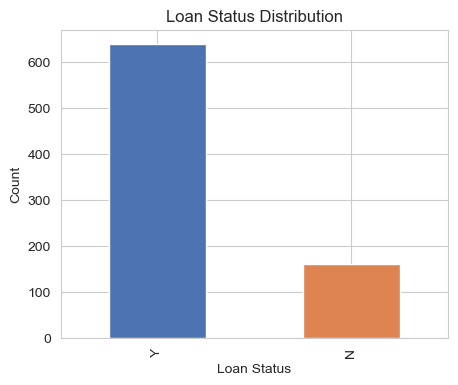

Loan_Status
Y    0.79875
N    0.20125
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5,4))
df['Loan_Status'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

print(df['Loan_Status'].value_counts(normalize=True))


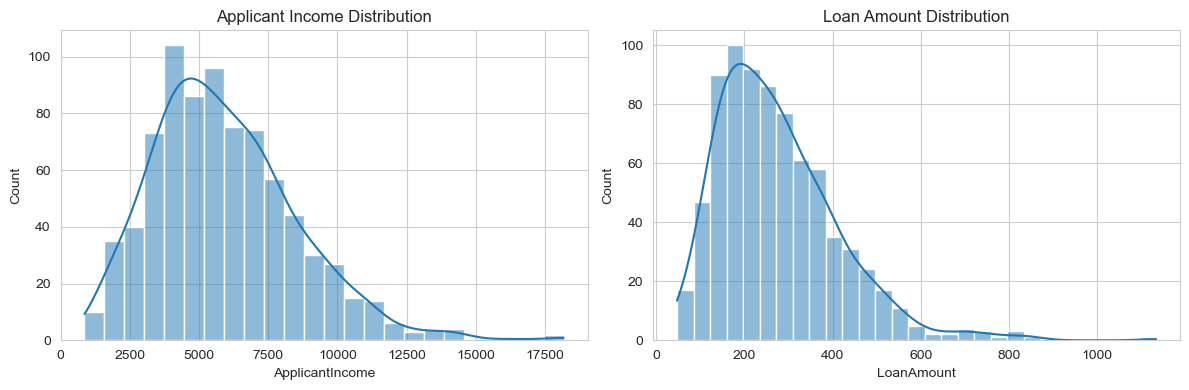

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ApplicantIncome'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Applicant Income Distribution')

sns.histplot(df['LoanAmount'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Loan Amount Distribution')
plt.tight_layout()
plt.show()


## 4. Handling Missing Values

Strategy:
- **Numeric columns** (`LoanAmount`, `Loan_Amount_Term`, `Credit_History`) → fill with **median**
- **Categorical columns** (`Gender`, `Married`, `Dependents`, `Self_Employed`) → fill with **mode**


In [8]:
numeric_missing = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
categorical_missing = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in numeric_missing:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 5. Feature Engineering

Ab hum naye, zyada informative features banayenge:

- **Total_Income** = ApplicantIncome + CoapplicantIncome
- **Loan_Income_Ratio** = LoanAmount / Total_Income (loan applicant ki income ke muqable kitna bada hai)
- **EMI** = LoanAmount / Loan_Amount_Term (approx monthly installment)
- **Balance_Income** = Total_Income − EMI (EMI dene ke baad kitni income bachti hai)
- **Dependents_Num** = Dependents ko numeric banana ('3+' → 3)
- **Log transforms** = skewed income/loan columns par log lagana taake distribution normal ho


In [9]:
# Total income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Loan to income ratio
df['Loan_Income_Ratio'] = df['LoanAmount'] / (df['Total_Income'] + 1)

# Approx EMI (LoanAmount is already in thousands in real Kaggle dataset; here treat as-is)
df['EMI'] = df['LoanAmount'] / (df['Loan_Amount_Term'] + 1)

# Balance income after EMI
df['Balance_Income'] = df['Total_Income'] - (df['EMI'] * 1000)

# Dependents as numeric
df['Dependents_Num'] = df['Dependents'].replace({'3+': '3'}).astype(int)

# Log transform skewed numeric columns
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['Total_Income_log'] = np.log1p(df['Total_Income'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

df[['Total_Income', 'Loan_Income_Ratio', 'EMI', 'Balance_Income',
    'Dependents_Num', 'ApplicantIncome_log', 'Total_Income_log', 'LoanAmount_log']].head()


,Total_Income,Loan_Income_Ratio,EMI,Balance_Income,Dependents_Num,ApplicantIncome_log,Total_Income_log,LoanAmount_log
0,8008.0,0.054813,1.216066,6791.933518,0,8.713418,8.988321,6.086775
1,11360.0,0.037937,1.193906,10166.094183,0,9.180293,9.337942,6.068426
2,8136.0,0.036131,0.814404,7321.595568,0,8.890411,9.004177,5.686975
3,4597.0,0.031100,0.396122,4200.878116,0,8.433377,8.433377,4.969813
4,6967.0,0.032434,0.626039,6340.961219,0,8.634265,8.849084,5.424950


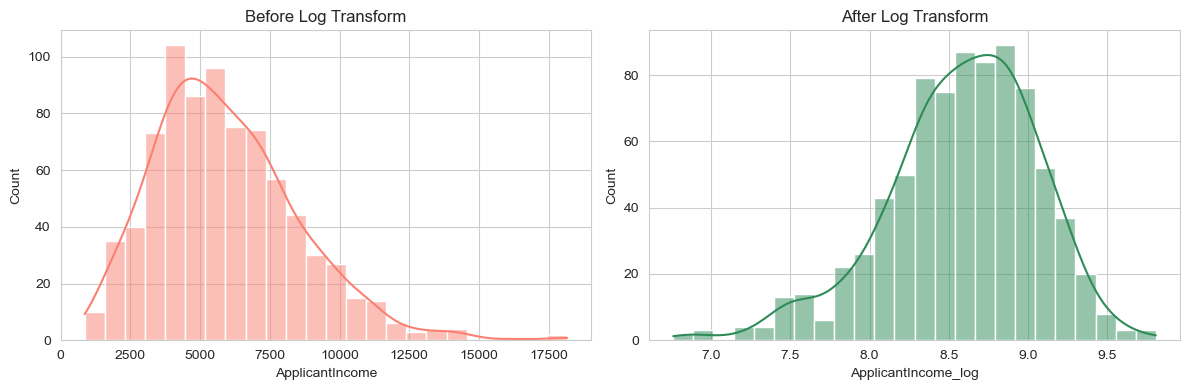

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Before Log Transform')

sns.histplot(df['ApplicantIncome_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('After Log Transform')
plt.tight_layout()
plt.show()


## 6. Encoding Categorical Variables

- **Binary categorical columns** (Gender, Married, Education, Self_Employed, Loan_Status) → Label Encoding
- **Multi-class categorical column** (Property_Area) → One-Hot Encoding


In [11]:
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Target column encoding
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# One-hot encode Property_Area
df = pd.get_dummies(df, columns=['Property_Area'], prefix='Area', drop_first=True)

# Drop the original Dependents column (we already made Dependents_Num)
df = df.drop(columns=['Dependents'])

df.head()


,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Loan_Income_Ratio,EMI,Balance_Income,Dependents_Num,ApplicantIncome_log,Total_Income_log,LoanAmount_log,Area_Semiurban,Area_Urban
0,1,0,0,0,6083.0,1925.0,439.0,360.0,1.0,1,8008.0,0.054813,1.216066,6791.933518,0,8.713418,8.988321,6.086775,True,False
1,0,1,0,0,9703.0,1657.0,431.0,360.0,0.0,0,11360.0,0.037937,1.193906,10166.094183,0,9.180293,9.337942,6.068426,False,False
2,1,1,0,0,7261.0,875.0,294.0,360.0,1.0,1,8136.0,0.036131,0.814404,7321.595568,0,8.890411,9.004177,5.686975,False,False
3,1,1,0,0,4597.0,0.0,143.0,360.0,1.0,1,4597.0,0.031100,0.396122,4200.878116,0,8.433377,8.433377,4.969813,False,True
4,1,1,0,0,5620.0,1347.0,226.0,360.0,1.0,1,6967.0,0.032434,0.626039,6340.961219,0,8.634265,8.849084,5.424950,False,True


## 7. Feature Scaling

Numeric columns ko StandardScaler se scale karenge taake sab features similar range mein aa jayein — yeh especially Logistic Regression jaise distance/gradient-based models ke liye zaroori hai.


In [12]:
scale_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income',
              'EMI', 'Balance_Income', 'Loan_Income_Ratio']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

df_scaled[scale_cols].describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Total_Income,EMI,Balance_Income,Loan_Income_Ratio
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,1.587619e-16,8.881784e-17,-8.104628e-17,2.220446e-18,-8.881784e-17,-7.549517e-17,-1.421085e-16
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.939555e+00,-9.372495e-01,-1.680796e+00,-2.081257e+00,-8.340364e-01,-2.537430e+00,-1.588488e+00
25%,-6.957758e-01,-9.372495e-01,-7.393501e-01,-7.490480e-01,-4.876817e-01,-6.725762e-01,-8.044777e-01
50%,-1.347317e-01,-2.180956e-01,-1.759651e-01,-1.294481e-01,-2.789514e-01,-9.247019e-02,-2.504576e-01
75%,5.902303e-01,4.684076e-01,5.208531e-01,5.853956e-01,8.389345e-02,6.030121e-01,6.115010e-01
max,4.703146e+00,4.835238e+00,6.377092e+00,4.658698e+00,1.075702e+01,4.860207e+00,7.454548e+00


## 8. Feature Selection

Correlation matrix dekh kar hum samjhenge kaun se features `Loan_Status` ke saath sabse zyada correlated hain.


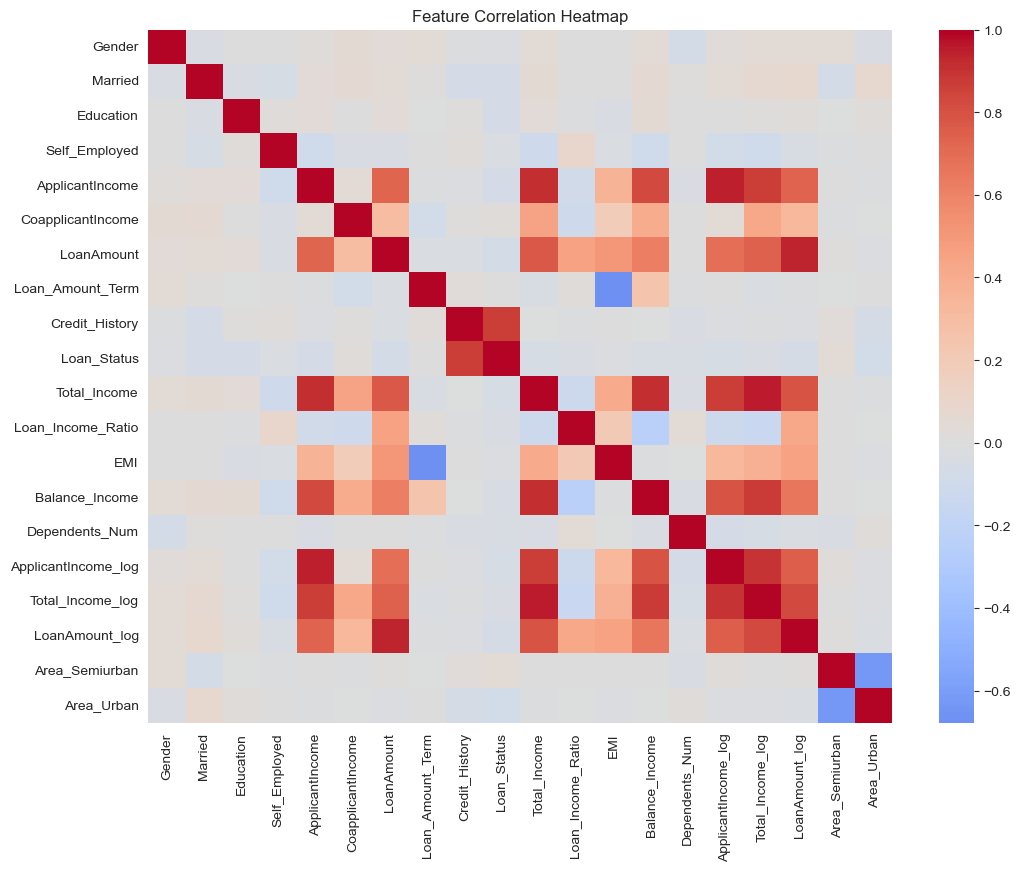

In [13]:
plt.figure(figsize=(12, 9))
corr = df_scaled.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


In [14]:
target_corr = corr['Loan_Status'].drop('Loan_Status').sort_values(key=abs, ascending=False)
print("Features sorted by correlation with Loan_Status:\n")
print(target_corr)


Features sorted by correlation with Loan_Status:

Credit_History         0.864489
Area_Urban            -0.075922
LoanAmount            -0.071883
ApplicantIncome       -0.065745
Married               -0.065130
Education             -0.061297
LoanAmount_log        -0.057021
ApplicantIncome_log   -0.051576
Total_Income          -0.049280
Balance_Income        -0.044055
Dependents_Num        -0.042639
Area_Semiurban         0.038208
Total_Income_log      -0.036113
Loan_Income_Ratio     -0.035106
Self_Employed         -0.025099
CoapplicantIncome      0.023391
EMI                   -0.021670
Gender                -0.017147
Loan_Amount_Term       0.008610
Name: Loan_Status, dtype: float64


In [15]:
# Drop raw/log-duplicate columns that are now redundant after feature engineering
drop_cols = ['ApplicantIncome_log', 'Total_Income_log', 'LoanAmount_log']
df_final = df_scaled.drop(columns=drop_cols)

print("Final feature set:")
print(df_final.columns.tolist())


Final feature set:
['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Total_Income', 'Loan_Income_Ratio', 'EMI', 'Balance_Income', 'Dependents_Num', 'Area_Semiurban', 'Area_Urban']


## 9. Train-Test Split

In [16]:
X = df_final.drop(columns=['Loan_Status'])
y = df_final['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (640, 16)
Test shape: (160, 16)


## 10. Quick Baseline Model

Feature engineering ka asar dekhne ke liye ek simple Logistic Regression model train karte hain.


In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.94375

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.75      0.84        32
           1       0.94      0.99      0.97       128

    accuracy                           0.94       160
   macro avg       0.95      0.87      0.90       160
weighted avg       0.94      0.94      0.94       160



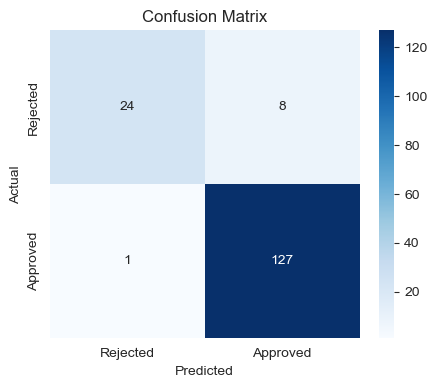

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


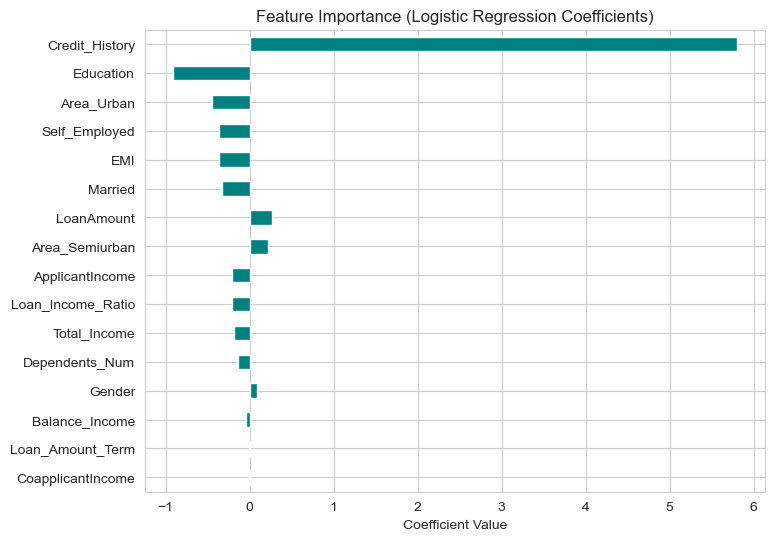

In [19]:
feat_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()


## 11. Conclusion

Is notebook mein humne complete **Feature Engineering pipeline** practice ki:

1. Missing values handle kiye (median/mode)
2. Naye meaningful features banaye: `Total_Income`, `Loan_Income_Ratio`, `EMI`, `Balance_Income`, `Dependents_Num`
3. Skewed columns par log transform apply kiya
4. Categorical variables ko Label Encoding aur One-Hot Encoding se numeric banaya
5. Numeric features ko StandardScaler se scale kiya
6. Correlation ke basis par feature selection ki
7. Ek baseline Logistic Regression model train kar ke feature importance dekhi

**Next steps (practice ke liye):**
- Different models try karein (Random Forest, XGBoost)
- Cross-validation use karein (K-Fold)
- Hyperparameter tuning karein (GridSearchCV / RandomizedSearchCV)
- Real Kaggle "Loan Prediction" dataset par yehi pipeline apply karein
